In [7]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path 
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT/"data"/"raw"/"california_housing.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df["MedHouseVal"].describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

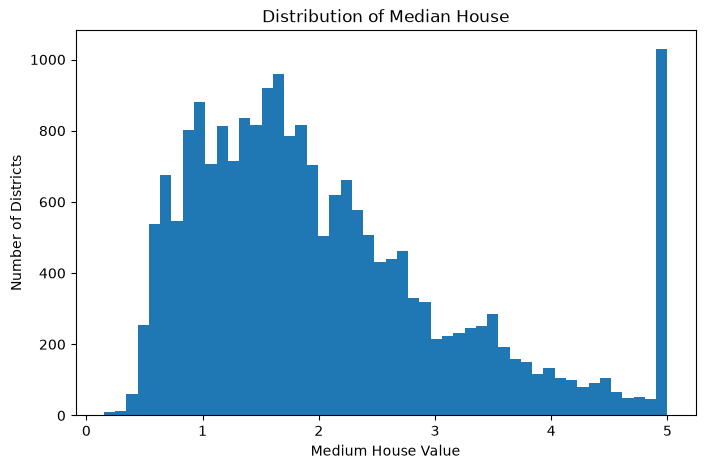

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["MedHouseVal"],bins=50)
plt.xlabel("Medium House Value")
plt.ylabel("Number of Districts")
plt.title("Distribution of Median House")
plt.show()


In [10]:
df[["AveRooms", "AveBedrms", "Population", "AveOccup"]].describe().T

,count,mean,std,min,25%,50%,75%,max
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333


In [12]:
df.nlargest(10, "AveOccup")[["AveOccup","MedInc","HouseAge","MedHouseVal"]]


,AveOccup,MedInc,HouseAge,MedHouseVal
19006,1243.333333,10.2264,45.0,1.37500
3364,599.714286,5.5179,36.0,0.67500
16669,502.461538,4.2639,46.0,3.50000
13034,230.172414,6.1359,52.0,2.25000
9172,83.171429,4.2391,5.0,1.54600
12104,63.750000,1.6250,8.0,1.62500
16420,51.400000,5.7485,26.0,1.62500
8874,41.214286,9.3370,52.0,5.00001
13366,33.952941,4.2578,36.0,1.83300
5986,21.333333,1.8750,52.0,2.12500


In [13]:
df.nlargest(10, "AveRooms")[["AveRooms","MedInc","HouseAge","MedHouseVal"]]


,AveRooms,MedInc,HouseAge,MedHouseVal
1914,141.909091,1.8750,33.0,5.00001
1979,132.533333,4.6250,34.0,1.62500
12447,62.422222,1.6154,17.0,0.87500
1913,61.812500,4.0714,19.0,4.37500
11862,59.875000,2.6250,25.0,0.67500
1912,56.269231,4.9750,16.0,2.06300
9676,52.848214,3.2431,14.0,2.21400
11707,52.690476,1.1912,22.0,1.70000
2395,50.837838,3.8750,23.0,1.25000
1240,47.515152,3.1250,11.0,0.77500


In [14]:
correlation = df.corr(numeric_only=True)

correlation["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

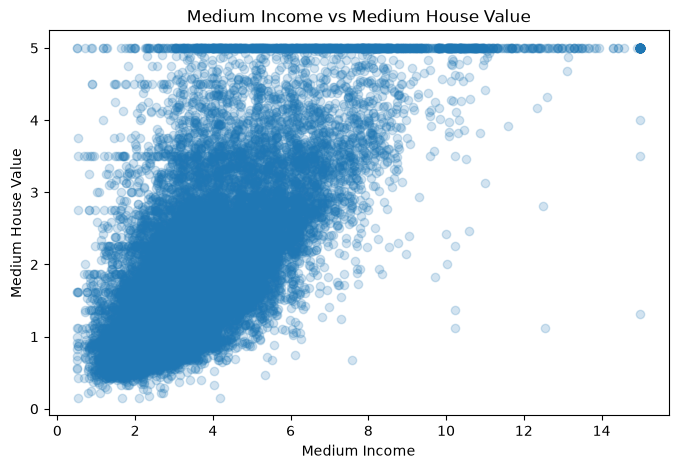

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.2
)
plt.xlabel("Medium Income")
plt.ylabel("Medium House Value")
plt.title("Medium Income vs Medium House Value")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split


In [18]:

#seperate features (X) from Target (y)
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully")


Model trained successfully


In [20]:
y_pred = model.predict(X_test)
print("Predictions generated:",len(y_pred))
print("First 10 predictions:")
print(y_pred[0:10])

Predictions generated: 4128
First 10 predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE:{mae:4f}")
print(f"RMSE:{rmse:4f}")
print(f"R^{2}:{r2:.4f}")



MAE:0.533200
RMSE:0.745581
R^2:0.5758


In [25]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred
})

comparison.head(20)

,Actual,Predicted,Error
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


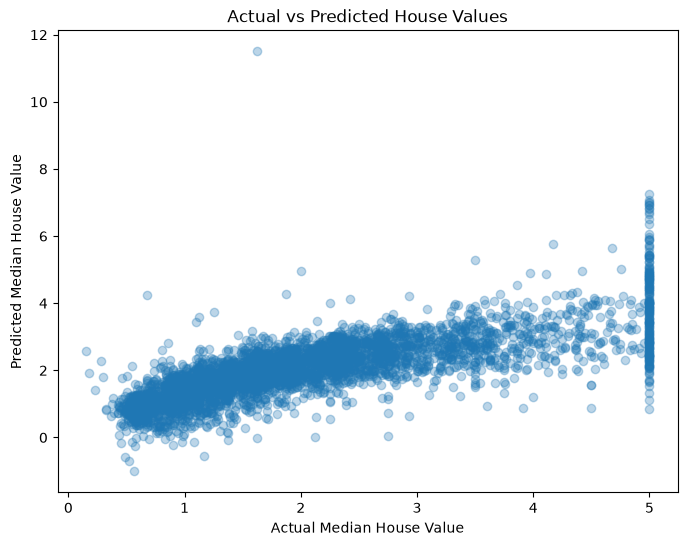

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [27]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [28]:
print("Intercept:", model.intercept_)

Intercept: -37.02327770606407
